In [255]:
import pandas as pd
import numpy as np
from scipy.stats import ttest_ind
import matplotlib.pyplot as plt
import seaborn as sns

## **1. Data Import and Cleaning:**

### **1.1 Importation des données**

In [256]:
df = pd.read_csv('global_power_plant_database.csv',low_memory=False)

In [257]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34936 entries, 0 to 34935
Data columns (total 36 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   country                         34936 non-null  object 
 1   country_long                    34936 non-null  object 
 2   name                            34936 non-null  object 
 3   gppd_idnr                       34936 non-null  object 
 4   capacity_mw                     34936 non-null  float64
 5   latitude                        34936 non-null  float64
 6   longitude                       34936 non-null  float64
 7   primary_fuel                    34936 non-null  object 
 8   other_fuel1                     1944 non-null   object 
 9   other_fuel2                     276 non-null    object 
 10  other_fuel3                     92 non-null     object 
 11  commissioning_year              17447 non-null  float64
 12  owner                           

Notre jeu de données est composé de 34936 échantillons et 36 variables

### **1.2 Valeurs manquantes**

In [258]:
print(df.isnull().sum())

country                               0
country_long                          0
name                                  0
gppd_idnr                             0
capacity_mw                           0
latitude                              0
longitude                             0
primary_fuel                          0
other_fuel1                       32992
other_fuel2                       34660
other_fuel3                       34844
commissioning_year                17489
owner                             14068
source                               15
url                                  18
geolocation_source                  419
wepp_id                           18702
year_of_capacity_data             20049
generation_gwh_2013               28519
generation_gwh_2014               27710
generation_gwh_2015               26733
generation_gwh_2016               25792
generation_gwh_2017               25436
generation_gwh_2018               25299
generation_gwh_2019               25277


In [259]:
df['other_fuel1'].unique()

array([nan, 'Oil', 'Solar', 'Gas', 'Other', 'Hydro', 'Coal', 'Petcoke',
       'Biomass', 'Waste', 'Cogeneration', 'Storage', 'Wind'],
      dtype=object)

In [260]:
df['other_fuel2'].unique()

array([nan, 'Other', 'Oil', 'Biomass', 'Gas', 'Solar', 'Waste', 'Storage',
       'Hydro', 'Wind', 'Coal', 'Petcoke'], dtype=object)

In [261]:
df['other_fuel3'].unique()

array([nan, 'Other', 'Gas', 'Solar', 'Biomass', 'Hydro', 'Oil', 'Wind',
       'Storage'], dtype=object)

Ici vuee que le nombre de valeurs nulle est nombreuses dans ces trois variables (other_fuel1,other_fuel2, other_fuel3) afin de voir s'ils contiennent les mêmes informations, et vu qu'ils contiennent les mêmes informations, je vais les déplacer dans une autre variables et les récupérer après si besoin

In [262]:
other_fuel = df[['other_fuel1','other_fuel2','other_fuel3']]
df  = df.drop(['other_fuel1','other_fuel2','other_fuel3'],axis=1)

In [263]:
df.isnull().sum()

country                               0
country_long                          0
name                                  0
gppd_idnr                             0
capacity_mw                           0
latitude                              0
longitude                             0
primary_fuel                          0
commissioning_year                17489
owner                             14068
source                               15
url                                  18
geolocation_source                  419
wepp_id                           18702
year_of_capacity_data             20049
generation_gwh_2013               28519
generation_gwh_2014               27710
generation_gwh_2015               26733
generation_gwh_2016               25792
generation_gwh_2017               25436
generation_gwh_2018               25299
generation_gwh_2019               25277
generation_data_source            23536
estimated_generation_gwh_2013     18816
estimated_generation_gwh_2014     18433


In [264]:
df.iloc[:,8:-5].isnull().sum()

commissioning_year               17489
owner                            14068
source                              15
url                                 18
geolocation_source                 419
wepp_id                          18702
year_of_capacity_data            20049
generation_gwh_2013              28519
generation_gwh_2014              27710
generation_gwh_2015              26733
generation_gwh_2016              25792
generation_gwh_2017              25436
generation_gwh_2018              25299
generation_gwh_2019              25277
generation_data_source           23536
estimated_generation_gwh_2013    18816
estimated_generation_gwh_2014    18433
estimated_generation_gwh_2015    17886
estimated_generation_gwh_2016    17366
estimated_generation_gwh_2017     1798
dtype: int64

Ici, j'utilise le slicing pour voir toutes mes variables ou il y a des données manquantes

In [265]:
df = df[df['url'].notnull()&df['source'].notnull()]

In [266]:
df.iloc[:,8:-5].isnull().sum()

commissioning_year               17473
owner                            14052
source                               0
url                                  0
geolocation_source                 419
wepp_id                          18684
year_of_capacity_data            20031
generation_gwh_2013              28501
generation_gwh_2014              27692
generation_gwh_2015              26715
generation_gwh_2016              25774
generation_gwh_2017              25418
generation_gwh_2018              25281
generation_gwh_2019              25259
generation_data_source           23518
estimated_generation_gwh_2013    18801
estimated_generation_gwh_2014    18418
estimated_generation_gwh_2015    17871
estimated_generation_gwh_2016    17351
estimated_generation_gwh_2017     1798
dtype: int64

In [267]:
df['geolocation_source'] = df['geolocation_source'].fillna('No specify')

In [268]:
df.iloc[:,8:-5].isnull().sum()

commissioning_year               17473
owner                            14052
source                               0
url                                  0
geolocation_source                   0
wepp_id                          18684
year_of_capacity_data            20031
generation_gwh_2013              28501
generation_gwh_2014              27692
generation_gwh_2015              26715
generation_gwh_2016              25774
generation_gwh_2017              25418
generation_gwh_2018              25281
generation_gwh_2019              25259
generation_data_source           23518
estimated_generation_gwh_2013    18801
estimated_generation_gwh_2014    18418
estimated_generation_gwh_2015    17871
estimated_generation_gwh_2016    17351
estimated_generation_gwh_2017     1798
dtype: int64

In [269]:
df['estimated_generation_gwh_2017'].mean()

np.float64(715.8833070652173)

<Axes: xlabel='estimated_generation_gwh_2017', ylabel='Count'>

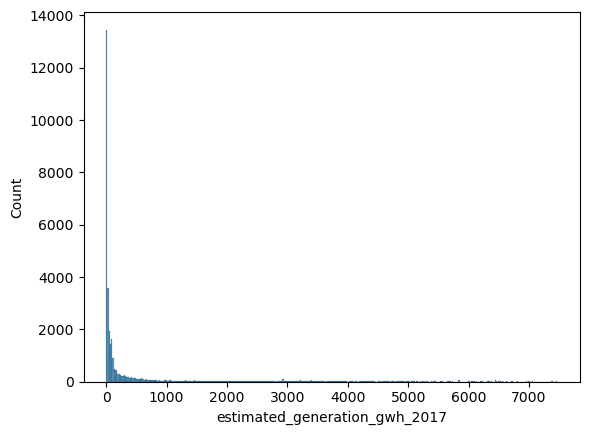

In [270]:
sns.histplot(df[df['estimated_generation_gwh_2017']<7500]['estimated_generation_gwh_2017'])

Vu que la variable ne suit pas une loi normale, il plus préférable de remplacer les valeurs manquantes de 'estimated_generation_gwh_2017' par la médiane 

In [271]:
df.iloc[:,8:-5].isnull().sum()

commissioning_year               17473
owner                            14052
source                               0
url                                  0
geolocation_source                   0
wepp_id                          18684
year_of_capacity_data            20031
generation_gwh_2013              28501
generation_gwh_2014              27692
generation_gwh_2015              26715
generation_gwh_2016              25774
generation_gwh_2017              25418
generation_gwh_2018              25281
generation_gwh_2019              25259
generation_data_source           23518
estimated_generation_gwh_2013    18801
estimated_generation_gwh_2014    18418
estimated_generation_gwh_2015    17871
estimated_generation_gwh_2016    17351
estimated_generation_gwh_2017     1798
dtype: int64

In [272]:
df['estimated_generation_gwh_2017'] = df['estimated_generation_gwh_2017'].fillna(df['estimated_generation_gwh_2017'].median())

In [273]:
df.iloc[:,8:-5].isnull().sum()

commissioning_year               17473
owner                            14052
source                               0
url                                  0
geolocation_source                   0
wepp_id                          18684
year_of_capacity_data            20031
generation_gwh_2013              28501
generation_gwh_2014              27692
generation_gwh_2015              26715
generation_gwh_2016              25774
generation_gwh_2017              25418
generation_gwh_2018              25281
generation_gwh_2019              25259
generation_data_source           23518
estimated_generation_gwh_2013    18801
estimated_generation_gwh_2014    18418
estimated_generation_gwh_2015    17871
estimated_generation_gwh_2016    17351
estimated_generation_gwh_2017        0
dtype: int64

In [274]:
df['commissioning_year'] = (
    df.groupby('primary_fuel')['commissioning_year']
      .transform(lambda x: x.fillna(x.median()))
)

/home/cyriac/miniforge3/envs/formation/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:1214: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)


Ici, on groupe commissionning_year et primary_fuel, ensuite on remplace les valeurs manquante par la médiane

In [275]:
df.iloc[:,8:-5].isnull().sum()

commissioning_year                  10
owner                            14052
source                               0
url                                  0
geolocation_source                   0
wepp_id                          18684
year_of_capacity_data            20031
generation_gwh_2013              28501
generation_gwh_2014              27692
generation_gwh_2015              26715
generation_gwh_2016              25774
generation_gwh_2017              25418
generation_gwh_2018              25281
generation_gwh_2019              25259
generation_data_source           23518
estimated_generation_gwh_2013    18801
estimated_generation_gwh_2014    18418
estimated_generation_gwh_2015    17871
estimated_generation_gwh_2016    17351
estimated_generation_gwh_2017        0
dtype: int64

In [276]:
df = df[df['commissioning_year'].notnull()]

In [277]:
df.iloc[:,8:-5].isnull().sum()

commissioning_year                   0
owner                            14051
source                               0
url                                  0
geolocation_source                   0
wepp_id                          18679
year_of_capacity_data            20022
generation_gwh_2013              28491
generation_gwh_2014              27682
generation_gwh_2015              26705
generation_gwh_2016              25764
generation_gwh_2017              25408
generation_gwh_2018              25271
generation_gwh_2019              25249
generation_data_source           23508
estimated_generation_gwh_2013    18791
estimated_generation_gwh_2014    18408
estimated_generation_gwh_2015    17861
estimated_generation_gwh_2016    17341
estimated_generation_gwh_2017        0
dtype: int64

In [278]:
df['owner'].unique()

array([nan, "SociÃ©te AlgÃ©rienne de Production de l\\'ElectricitÃ©",
       'SociÃ©tÃ© AlgÃ©rienne de Production de lâ€™ElectricitÃ© (SPE)',
       ..., 'ZESCO', 'Maamba Collieries', 'Zambia Sugar'],
      shape=(10138,), dtype=object)

Ici, vu qu'il assez d'information différente, nous ne trouvons pas ça idéal de laisser la colonne surtout qu'elle comportait beaucoup de valeur manquante

In [279]:
owner = df['owner']
df = df.drop('owner',axis=1)

In [280]:
df.iloc[:,8:-5].isnull().sum()

commissioning_year                   0
source                               0
url                                  0
geolocation_source                   0
wepp_id                          18679
year_of_capacity_data            20022
generation_gwh_2013              28491
generation_gwh_2014              27682
generation_gwh_2015              26705
generation_gwh_2016              25764
generation_gwh_2017              25408
generation_gwh_2018              25271
generation_gwh_2019              25249
generation_data_source           23508
estimated_generation_gwh_2013    18791
estimated_generation_gwh_2014    18408
estimated_generation_gwh_2015    17861
estimated_generation_gwh_2016    17341
estimated_generation_gwh_2017        0
dtype: int64

In [281]:
df = df.drop('wepp_id',axis=1)

In [282]:
df.iloc[:,8:-5].isnull().sum()

commissioning_year                   0
source                               0
url                                  0
geolocation_source                   0
year_of_capacity_data            20022
generation_gwh_2013              28491
generation_gwh_2014              27682
generation_gwh_2015              26705
generation_gwh_2016              25764
generation_gwh_2017              25408
generation_gwh_2018              25271
generation_gwh_2019              25249
generation_data_source           23508
estimated_generation_gwh_2013    18791
estimated_generation_gwh_2014    18408
estimated_generation_gwh_2015    17861
estimated_generation_gwh_2016    17341
estimated_generation_gwh_2017        0
dtype: int64

In [283]:
df = df.drop('year_of_capacity_data',axis=1)

In [284]:
df.iloc[:,8:-5].isnull().sum()

commissioning_year                   0
source                               0
url                                  0
geolocation_source                   0
generation_gwh_2013              28491
generation_gwh_2014              27682
generation_gwh_2015              26705
generation_gwh_2016              25764
generation_gwh_2017              25408
generation_gwh_2018              25271
generation_gwh_2019              25249
generation_data_source           23508
estimated_generation_gwh_2013    18791
estimated_generation_gwh_2014    18408
estimated_generation_gwh_2015    17861
estimated_generation_gwh_2016    17341
estimated_generation_gwh_2017        0
dtype: int64

In [285]:
generation_gwh = df[['generation_gwh_2013','generation_gwh_2014','generation_gwh_2015',
                              'generation_gwh_2016', 'generation_gwh_2017','generation_gwh_2018','generation_gwh_2019']]

In [286]:
df = df.drop(['generation_gwh_2013','generation_gwh_2014','generation_gwh_2015',
                              'generation_gwh_2016', 'generation_gwh_2017','generation_gwh_2018','generation_gwh_2019'],axis= 1)

In [287]:
df.iloc[:,8:-5].isnull().sum()

commissioning_year                   0
source                               0
url                                  0
geolocation_source                   0
generation_data_source           23508
estimated_generation_gwh_2013    18791
estimated_generation_gwh_2014    18408
estimated_generation_gwh_2015    17861
estimated_generation_gwh_2016    17341
estimated_generation_gwh_2017        0
dtype: int64

In [288]:
df['generation_data_source'].unique()

array([nan, 'Australia Clean Energy Regulator', 'JRC-PPDB-OPEN', 'ENTSOE',
       'Agencia de Regulacion y Control de Electricidad',
       'Egyptian Electricity Holding Company', 'IAEA',
       'Volta River Authority',
       'Guatemala Energy Data Visualization Center at Universidad Rafael Landivar',
       'Central Electricity Authority', 'Arab Union of Electricity',
       "Office National de l'Electricite", 'Open Development Myanmar',
       'Wind Stats Netherlands', 'Peru Ministry of Energy and Mines',
       'U.S. Energy Information Administration',
       'Venezuela Electricity Sector', 'Open Development Vietnam'],
      dtype=object)

Vu que c'est une variable catégorielle, on va remplacer la valeur nulle par 'No speciy'

In [289]:
df['generation_data_source'] = df['generation_data_source'].fillna('No Specify')

In [290]:
df.iloc[:,8:-5].isnull().sum()

commissioning_year                   0
source                               0
url                                  0
geolocation_source                   0
generation_data_source               0
estimated_generation_gwh_2013    18791
estimated_generation_gwh_2014    18408
estimated_generation_gwh_2015    17861
estimated_generation_gwh_2016    17341
estimated_generation_gwh_2017        0
dtype: int64

Pour les estimation_generation_gwh, vu qu'il y a beaucoup de donnée manquante, je vais garder pour 2017et supprimer les autres, car elle représente plus de 50% de nos donnée, donc les imputer créer beaucoup trop de donnée artificielle

In [291]:
estimated_generation_gwh = df[[
        'estimated_generation_gwh_2013',
        'estimated_generation_gwh_2014',
        'estimated_generation_gwh_2015',
        'estimated_generation_gwh_2016'
    ]]

In [292]:
df = df.drop([
        'estimated_generation_gwh_2013',
        'estimated_generation_gwh_2014',
        'estimated_generation_gwh_2015',
        'estimated_generation_gwh_2016'
    ],axis=1)

In [293]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 34908 entries, 0 to 34935
Data columns (total 19 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   country                         34908 non-null  object 
 1   country_long                    34908 non-null  object 
 2   name                            34908 non-null  object 
 3   gppd_idnr                       34908 non-null  object 
 4   capacity_mw                     34908 non-null  float64
 5   latitude                        34908 non-null  float64
 6   longitude                       34908 non-null  float64
 7   primary_fuel                    34908 non-null  object 
 8   commissioning_year              34908 non-null  float64
 9   source                          34908 non-null  object 
 10  url                             34908 non-null  object 
 11  geolocation_source              34908 non-null  object 
 12  generation_data_source          34908

In [294]:
df.isnull().sum()

country                           0
country_long                      0
name                              0
gppd_idnr                         0
capacity_mw                       0
latitude                          0
longitude                         0
primary_fuel                      0
commissioning_year                0
source                            0
url                               0
geolocation_source                0
generation_data_source            0
estimated_generation_gwh_2017     0
estimated_generation_note_2013    0
estimated_generation_note_2014    0
estimated_generation_note_2015    0
estimated_generation_note_2016    0
estimated_generation_note_2017    0
dtype: int64

In [295]:
df['url'].unique()

array(['http://globalenergyobservatory.org', 'https://www.wiki-solar.org',
       'http://www.energycharter.org/fileadmin/DocumentsMedia/IDEER/IDEER-Albania_2013_en.pdf',
       ...,
       'https://data.opendevelopmentmekong.net/vi/library_record/za-hung-hydropower',
       'https://web.archive.org/web/20150318014800/http://www.pec.com.ye/',
       'http://www.erb.org.zm/reports/EnergySectorReport2014.pdf'],
      shape=(4869,), dtype=object)

In [296]:
df = df.drop(['name','url'],axis=1)

In [297]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 34908 entries, 0 to 34935
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   country                         34908 non-null  object 
 1   country_long                    34908 non-null  object 
 2   gppd_idnr                       34908 non-null  object 
 3   capacity_mw                     34908 non-null  float64
 4   latitude                        34908 non-null  float64
 5   longitude                       34908 non-null  float64
 6   primary_fuel                    34908 non-null  object 
 7   commissioning_year              34908 non-null  float64
 8   source                          34908 non-null  object 
 9   geolocation_source              34908 non-null  object 
 10  generation_data_source          34908 non-null  object 
 11  estimated_generation_gwh_2017   34908 non-null  float64
 12  estimated_generation_note_2013  34908

In [298]:
df = df.drop('gppd_idnr',axis=1)
df = df.drop('country_long',axis=1)

In [299]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 34908 entries, 0 to 34935
Data columns (total 15 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   country                         34908 non-null  object 
 1   capacity_mw                     34908 non-null  float64
 2   latitude                        34908 non-null  float64
 3   longitude                       34908 non-null  float64
 4   primary_fuel                    34908 non-null  object 
 5   commissioning_year              34908 non-null  float64
 6   source                          34908 non-null  object 
 7   geolocation_source              34908 non-null  object 
 8   generation_data_source          34908 non-null  object 
 9   estimated_generation_gwh_2017   34908 non-null  float64
 10  estimated_generation_note_2013  34908 non-null  object 
 11  estimated_generation_note_2014  34908 non-null  object 
 12  estimated_generation_note_2015  34908

Ici vu que estimated_generation_note partage à peu prêt les informations, nous allons garder la plus récente des informations, c'est à dire 2027

In [300]:
estimated_generation_note = df[[
        'estimated_generation_note_2013',
        'estimated_generation_note_2014',
        'estimated_generation_note_2015',
        'estimated_generation_note_2016'
    ]]

df = df.drop([
        'estimated_generation_note_2013',
        'estimated_generation_note_2014',
        'estimated_generation_note_2015',
        'estimated_generation_note_2016'
    ],axis=1)

In [301]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 34908 entries, 0 to 34935
Data columns (total 11 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   country                         34908 non-null  object 
 1   capacity_mw                     34908 non-null  float64
 2   latitude                        34908 non-null  float64
 3   longitude                       34908 non-null  float64
 4   primary_fuel                    34908 non-null  object 
 5   commissioning_year              34908 non-null  float64
 6   source                          34908 non-null  object 
 7   geolocation_source              34908 non-null  object 
 8   generation_data_source          34908 non-null  object 
 9   estimated_generation_gwh_2017   34908 non-null  float64
 10  estimated_generation_note_2017  34908 non-null  object 
dtypes: float64(5), object(6)
memory usage: 3.2+ MB


On peut maintenant passer à la prochaine étape qui la vérification de doublon

In [302]:
df.duplicated().sum()

np.int64(125)

In [303]:
df = df.drop_duplicates()

In [304]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 34783 entries, 0 to 34935
Data columns (total 11 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   country                         34783 non-null  object 
 1   capacity_mw                     34783 non-null  float64
 2   latitude                        34783 non-null  float64
 3   longitude                       34783 non-null  float64
 4   primary_fuel                    34783 non-null  object 
 5   commissioning_year              34783 non-null  float64
 6   source                          34783 non-null  object 
 7   geolocation_source              34783 non-null  object 
 8   generation_data_source          34783 non-null  object 
 9   estimated_generation_gwh_2017   34783 non-null  float64
 10  estimated_generation_note_2017  34783 non-null  object 
dtypes: float64(5), object(6)
memory usage: 3.2+ MB


In [305]:
df['commissioning_year'] = df['commissioning_year'].astype(int)

In [306]:
df.head()

,country,capacity_mw,latitude,longitude,primary_fuel,commissioning_year,source,geolocation_source,generation_data_source,estimated_generation_gwh_2017,estimated_generation_note_2017
0,AFG,33.0,32.322,65.1190,Hydro,1979,GEODB,GEODB,No Specify,119.50,HYDRO-V1
1,AFG,10.0,31.670,65.7950,Solar,2016,Wiki-Solar,Wiki-Solar,No Specify,18.29,SOLAR-V1-NO-AGE
2,AFG,10.0,31.623,65.7920,Solar,2016,Wiki-Solar,Wiki-Solar,No Specify,18.72,SOLAR-V1-NO-AGE
3,AFG,66.0,34.556,69.4787,Hydro,1979,GEODB,GEODB,No Specify,174.91,HYDRO-V1
4,AFG,100.0,34.641,69.7170,Hydro,1979,GEODB,GEODB,No Specify,350.80,HYDRO-V1


In [307]:
source = df['source']
df = df.drop('source',axis=1)

## **2. Exploratory Data Analysis:**

### **Statistiques descriptives**

In [308]:
df.describe()

,capacity_mw,latitude,longitude,commissioning_year,estimated_generation_gwh_2017
count,34783.000000,34783.000000,34783.000000,34783.000000,34783.000000
mean,163.629382,32.801875,-6.921157,2001.165052,682.734814
std,490.479187,22.649898,78.431696,19.635561,2428.479797
min,1.000000,-77.847000,-179.977700,1896.000000,0.000000
25%,4.900000,29.253450,-77.642300,1993.000000,8.980000
50%,16.800000,39.734000,-2.095100,2010.000000,37.555000
75%,75.950000,46.251200,49.652400,2016.000000,196.265000
max,22500.000000,71.292000,179.388700,2020.000000,82810.770000


In [330]:
#Moyenne
df.mean(numeric_only=True)

capacity_mw                       163.629382
latitude                           32.801875
longitude                          -6.921157
commissioning_year               2001.165052
estimated_generation_gwh_2017     682.734814
dtype: float64

In [331]:
#Médiane
df.median(numeric_only=True)

capacity_mw                        16.8000
latitude                           39.7340
longitude                          -2.0951
commissioning_year               2010.0000
estimated_generation_gwh_2017      37.5550
dtype: float64

In [333]:
#écart type
df.std(numeric_only=True)

capacity_mw                       490.479187
latitude                           22.649898
longitude                          78.431696
commissioning_year                 19.635561
estimated_generation_gwh_2017    2428.479797
dtype: float64

### **Répartition des centrales par pays**

In [312]:
df['country'].value_counts().head(15)

country
USA    9786
CHN    4229
GBR    2713
BRA    2355
FRA    2154
IND    1571
DEU    1309
CAN    1158
ESP     819
RUS     545
JPN     522
AUS     486
CZE     462
PRT     462
ITA     395
Name: count, dtype: int64

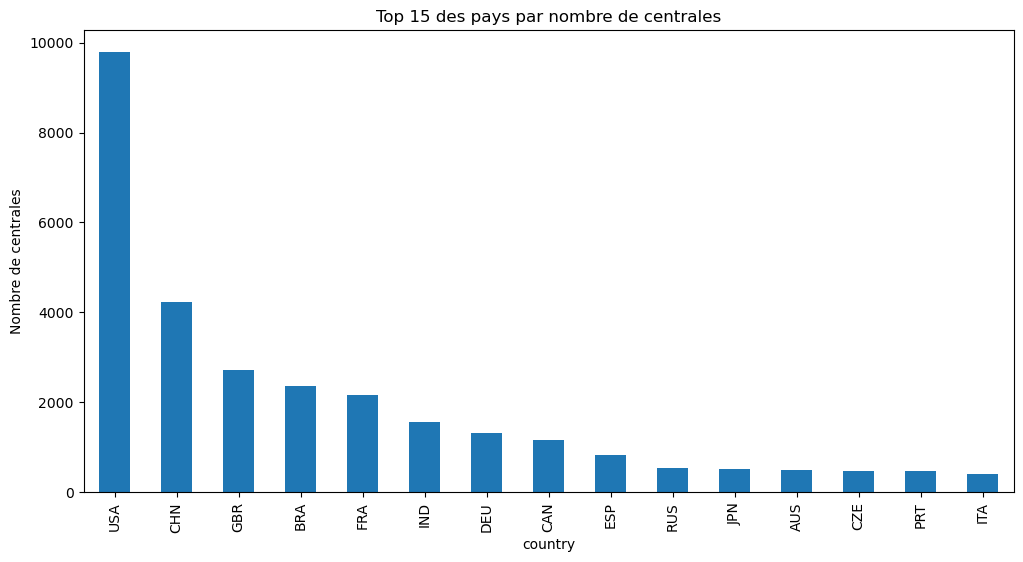

In [313]:
plt.figure(figsize=(12,6))

df['country'].value_counts().head(15).plot(kind="bar")

plt.title("Top 15 des pays par nombre de centrales")
plt.ylabel("Nombre de centrales")
plt.show()

Les USA sont le pays avec le plus de centrales 9786, suivient par la chine (4229)

### **Répartition par type de combustible**

In [314]:
fuel_count = df["primary_fuel"].value_counts()

fuel_count

primary_fuel
Solar           10590
Hydro            7153
Wind             5316
Gas              3981
Coal             2326
Oil              2311
Biomass          1428
Waste            1063
Nuclear           195
Geothermal        189
Storage           135
Other              43
Cogeneration       41
Petcoke            12
Name: count, dtype: int64

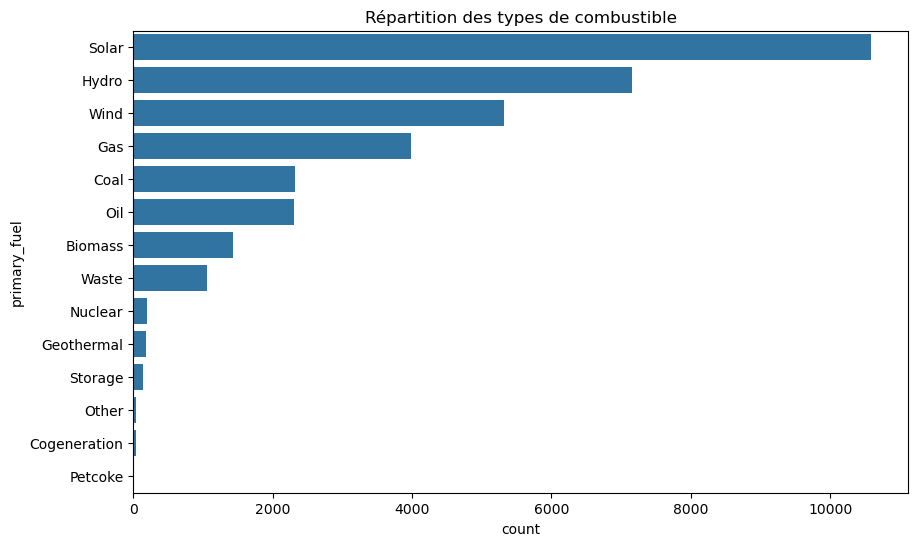

In [315]:
plt.figure(figsize=(10,6))

sns.countplot(
    y="primary_fuel",
    data=df,
    order=df["primary_fuel"].value_counts().index
)

plt.title("Répartition des types de combustible")
plt.show()

Le combustible solar est le plus utilisé (10590) et aussi l'hydro (7153)

## **3. Statistical Analysis:**

### **Puissance selon le combustible (Avec numpy)**

In [316]:
for fuel in df["primary_fuel"].unique():

    values = df[df["primary_fuel"]==fuel]["capacity_mw"]

    print(f"\n{fuel}")

    print("Moyenne :", np.mean(values))
    print("Médiane :", np.median(values))
    print("Écart-type :", np.std(values))


Hydro
Moyenne : 147.18022784845516
Médiane : 20.0
Écart-type : 549.8799170461896

Solar
Moyenne : 17.659926675165252
Médiane : 5.8
Écart-type : 42.05170937783922

Gas
Moyenne : 372.34378350891734
Médiane : 145.9
Écart-type : 561.4780779208716

Other
Moyenne : 84.02000000000001
Médiane : 40.0
Écart-type : 144.18500151009158

Oil
Moyenne : 112.96566404932929
Médiane : 9.0
Écart-type : 392.6294016445707

Wind
Moyenne : 49.263972817908204
Médiane : 27.0
Écart-type : 106.35579217856822

Nuclear
Moyenne : 2091.8551794871796
Médiane : 1888.0
Écart-type : 1300.1626458966462

Coal
Moyenne : 844.8267410146175
Médiane : 600.0
Écart-type : 888.2409681939637

Waste
Moyenne : 13.859279397930386
Médiane : 4.800000000000001
Écart-type : 20.607764883872164

Biomass
Moyenne : 24.00126162464986
Médiane : 9.55
Écart-type : 39.46821956192622

Petcoke
Moyenne : 202.048125
Médiane : 65.48875
Écart-type : 456.6797663310384

Geothermal
Moyenne : 67.13095238095238
Médiane : 30.0
Écart-type : 114.3372050672266


Pour chaque combustible, on essaie de déterminer la moyenne, la médiane et l'écart type

### **Test d'hypothèse**

H0 : Les moyennes sont identiques
H1 : Les moyennes sont différentes

In [317]:
coal = df[df["primary_fuel"]=="Coal"]["capacity_mw"]

gas = df[df["primary_fuel"]=="Gas"]["capacity_mw"]

In [318]:
t_stat, p_value = ttest_ind(
    coal,
    gas,
    equal_var=False
)

print(t_stat)
print(p_value)

if p_value < 0.05:
    print("Différence significative")
else:
    print("Pas de différence significative")

23.09461792975711
8.386107699493564e-110
Différence significative


Il existe une différence significative entre les moyennes, les moyennes sont donc différentes

## **4. Time Series Analysis:**

In [319]:
group_year = df.groupby("commissioning_year").size()

### **Tendance NumPy**

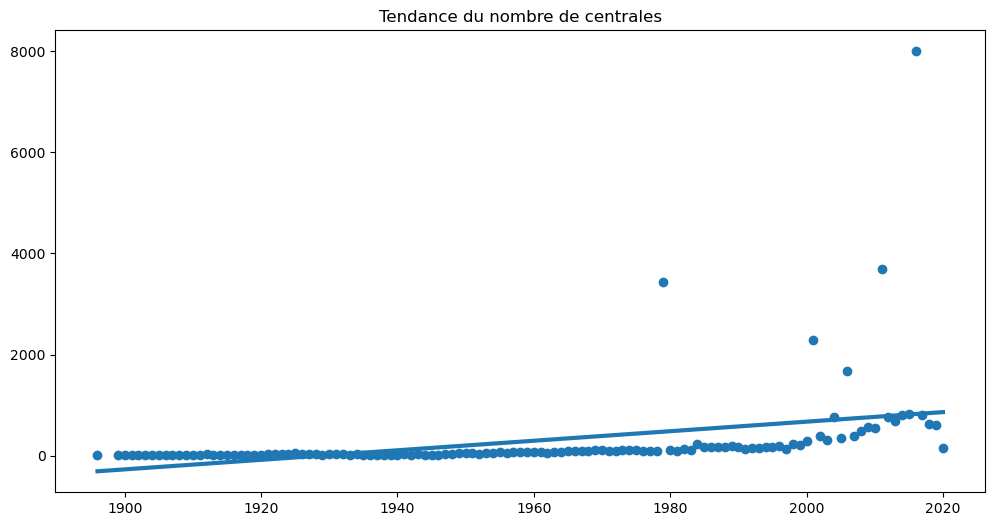

In [334]:
years = group_year.index.values
counts = group_year.values

coef = np.polyfit(years, counts, 1)

trend = np.poly1d(coef)

plt.figure(figsize=(12,6))

plt.scatter(years, counts)

plt.plot(years,
         trend(years),
         linewidth=3)

plt.title("Tendance du nombre de centrales")
plt.show()

On obtient une droite qui sépare nos données en deux groupe

### **Évolution du nombre de centrales**

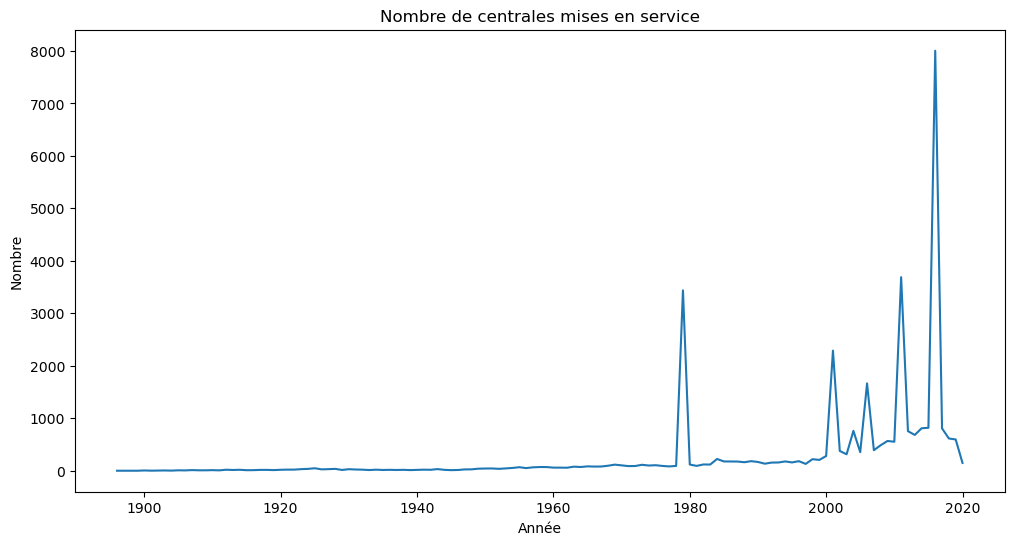

In [335]:
plt.figure(figsize=(12,6))

plt.plot(group_year.index,
         group_year.values)

plt.title("Nombre de centrales mises en service")
plt.xlabel("Année")
plt.ylabel("Nombre")
plt.show()

Le nombre de centrale a commencé à augmenter à partir des années 2000

## **5. Advanced Visualization:**

### **Distribution des capacités**

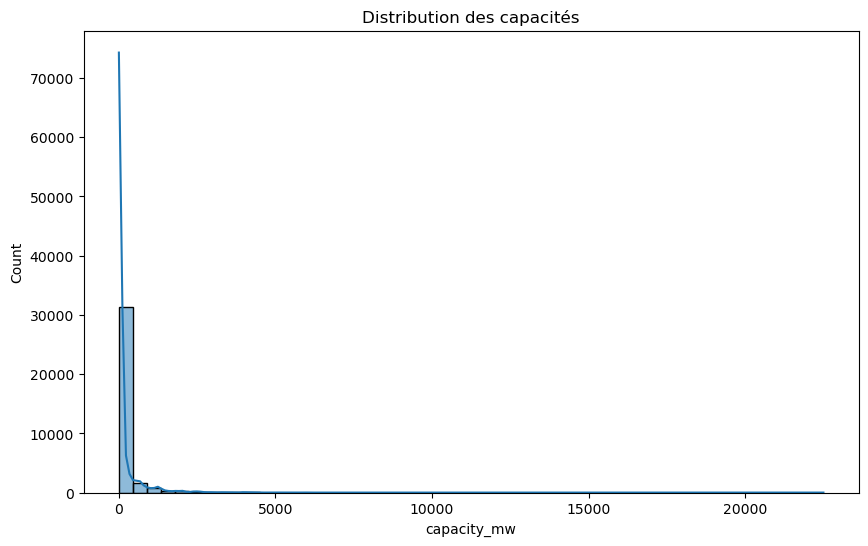

In [322]:
plt.figure(figsize=(10,6))

sns.histplot(
    df["capacity_mw"],
    bins=50,
    kde=True
)

plt.title("Distribution des capacités")
plt.show()

On constate que les donnée sont repartie de façon asymétrique et ne suivent pas le principe de la loi normale

### **Carte géographique**

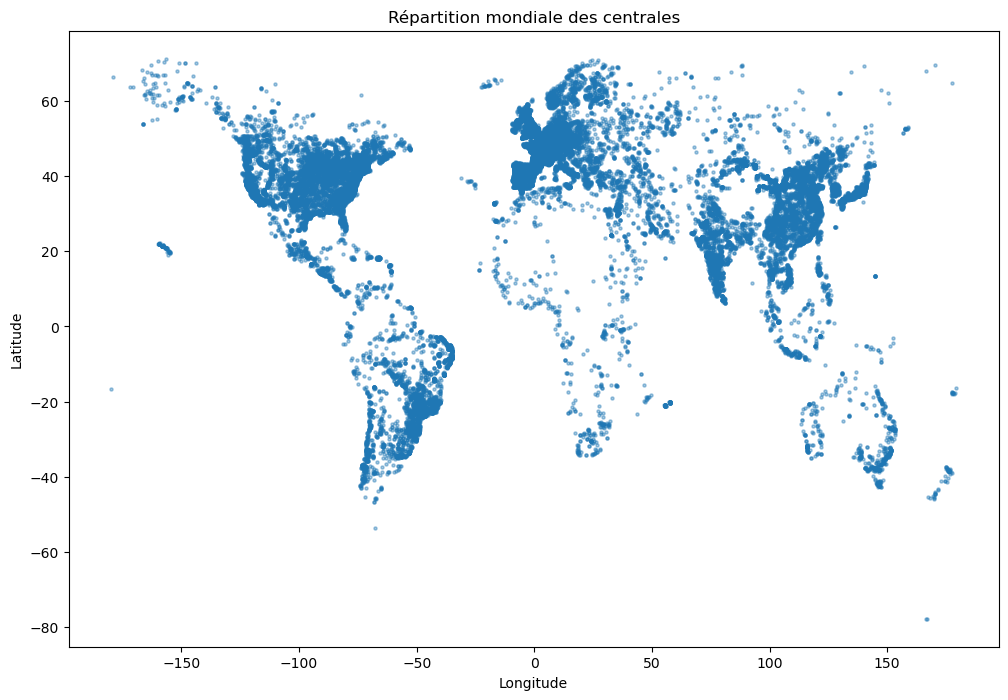

In [323]:
plt.figure(figsize=(12,8))

plt.scatter(
    df["longitude"],
    df["latitude"],
    alpha=0.4,
    s=5
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Répartition mondiale des centrales")
plt.show()

On peut voir la localisation des différent combustible

## **6. Matrix Operations in Real-World Context:**

### **Matrice de corrélation**

In [324]:
numeric_df = df.select_dtypes(
    include=np.number
)

In [325]:
corr_matrix = numeric_df.corr()

corr_matrix

,capacity_mw,latitude,longitude,commissioning_year,estimated_generation_gwh_2017
capacity_mw,1.000000,-0.013283,0.151706,-0.084042,0.946239
latitude,-0.013283,1.000000,-0.068214,-0.029552,-0.013696
longitude,0.151706,-0.068214,1.000000,0.110521,0.145218
commissioning_year,-0.084042,-0.029552,0.110521,1.000000,-0.074671
estimated_generation_gwh_2017,0.946239,-0.013696,0.145218,-0.074671,1.000000


On consate ici qu'il y a une forte corrélation entre capicity_mw et estimated_generation_gwh_2017

### **Avec numpy**

In [326]:
X = numeric_df.to_numpy()

corr_numpy = np.corrcoef(
    X,
    rowvar=False
)

In [327]:
corr_numpy

array([[ 1.        , -0.01328291,  0.15170609, -0.08404239,  0.94623874],
       [-0.01328291,  1.        , -0.06821411, -0.0295518 , -0.01369575],
       [ 0.15170609, -0.06821411,  1.        ,  0.11052137,  0.14521772],
       [-0.08404239, -0.0295518 ,  0.11052137,  1.        , -0.074671  ],
       [ 0.94623874, -0.01369575,  0.14521772, -0.074671  ,  1.        ]])

On obtient les même résultat

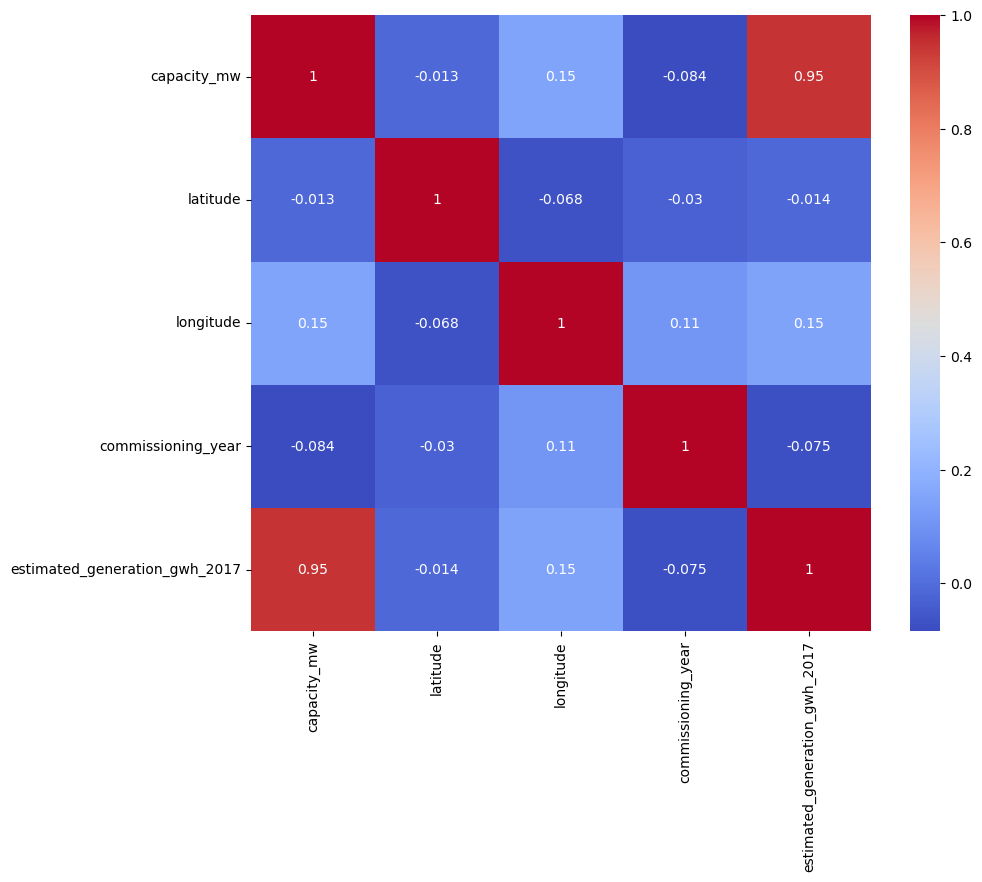

In [328]:
plt.figure(figsize=(10,8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm"
)

plt.show()

## **7. Integrating NumPy with Pandas and Matplotlib:**

### **Utilisation de NumPy pour une courbe de tendance**

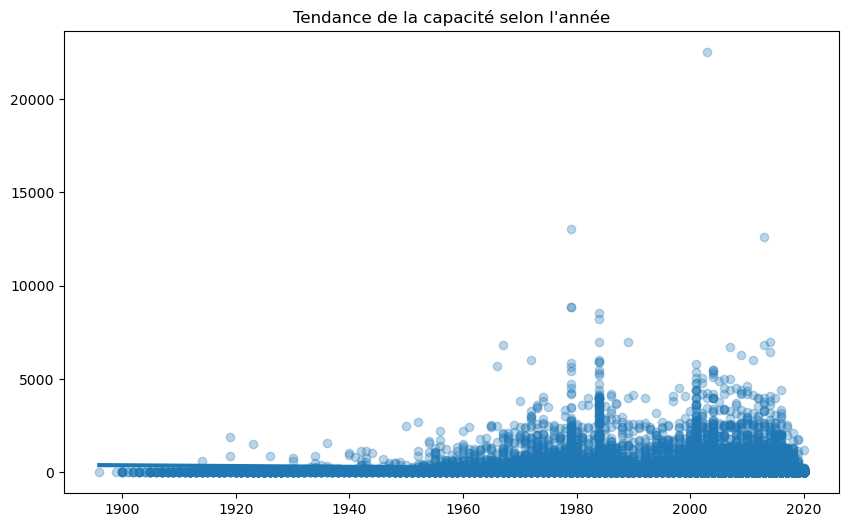

In [329]:
x = df["commissioning_year"].dropna()
y = df["capacity_mw"].loc[x.index]

coef = np.polyfit(x,y,1)

line = np.poly1d(coef)

plt.figure(figsize=(10,6))

plt.scatter(x,y,alpha=0.3)

plt.plot(
    np.sort(x),
    line(np.sort(x)),
    linewidth=3
)

plt.title(
    "Tendance de la capacité selon l'année"
)

plt.show()